In [1]:
calls = 0
def fib(n):
    global calls
    calls += 1
    if n < 2:
        return n
    return fib(n - 1) + fib(n - 2)

print(fib(30), "computed in", calls, "calls")

832040 computed in 2692537 calls


In [2]:
from functools import lru_cache


@lru_cache(maxsize=None)
def fib(n):
    if n < 2:
        return n
    return fib(n - 1) + fib(n - 2)

print(fib(30))
print(fib.cache_info())

832040
CacheInfo(hits=28, misses=31, maxsize=None, currsize=31)


In [3]:
import time

# Three functions with deliberately different complexity classes.
def constant_op(data):          # O(1): touch one element
    return data[0]

def linear_op(data):            # O(n): sum every element
    total = 0
    for x in data:
        total += x
    return total

def quadratic_op(data):         # O(n^2): compare every pair
    count = 0
    for a in data:
        for b in data:
            if a == b:
                count += 1
    return count

def time_it(func, n):
    data = list(range(n))
    start = time.perf_counter()
    func(data)
    return time.perf_counter() - start

sizes = [200, 400, 800, 1600, 3200]
for label, fn in [("O(1)", constant_op), ("O(n)", linear_op), ("O(n^2)", quadratic_op)]:
    row = [f"{time_it(fn, n)*1000:8.3f}" for n in sizes]
    print(f"{label:7}", "  ".join(row), "ms")
print("\nColumns = n:", sizes)

O(1)       0.001     0.001     0.000     0.000     0.000 ms
O(n)       0.013     0.021     0.039     0.067     0.093 ms
O(n^2)     1.262     6.111    12.816    52.915   163.682 ms

Columns = n: [200, 400, 800, 1600, 3200]


##### Time Complexities in increasing order of magnitude
* O(1)
* O(log n)
* O(n)
* O(n log n)
* O(n^2)
* O(n^3)
* O(2^n)
* O(k^n)
* O(n!)



## Arrays

* Homogeneous data type
* Contiguous
* Fixed size

**Array costs:**

| Operation | Cost | Why |
|---|---|---|
| index `lst[i]` | O(1) | address arithmetic |
| append | O(1)* | amortised; occasional resize |
| insert at front | **O(n)** | shift everything right |
| delete at front | **O(n)** | shift everything left |
| search by value | O(n) | scan |

In [4]:
sample = [10, 20, 30]
for i, value in enumerate(sample):
    print(f"index {i}: value={value}  id(value)={id(value)}")

index 0: value=10  id(value)=140727602506456
index 1: value=20  id(value)=140727602506776
index 2: value=30  id(value)=140727602507096


## Linked Lists

In [5]:
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None

class LinkedList:
    def __init__(self):
        self.head = None          # entry point to the chain

    def prepend(self, value):     # add at FRONT — O(1), just rewire head
        node = Node(value)
        node.next = self.head
        self.head = node

    def append(self, value):      # add at END — O(n), must walk to the tail
        node = Node(value)
        if self.head is None:
            self.head = node
            return
        cur = self.head
        while cur.next is not None:
            cur = cur.next
        cur.next = node

    def display(self):            # walk the chain, collect values
        out, cur = [], self.head
        while cur is not None:
            out.append(cur.value)
            cur = cur.next
        return out
    
#-----------------------------------------------------------------

chain = LinkedList()
for amount in [1500, 320, 9800]:
    chain.append(amount)
chain.prepend(75)                 # newest-first arrival at the front

print("chain:", chain.display())  # [75, 1500, 320, 9800]

chain: [75, 1500, 320, 9800]


In [6]:
N = 60000

# Array (list): insert at front N times -> each insert shifts everything -> O(n) each
arr = []
start = time.perf_counter()
for i in range(N):
    arr.insert(0, i)              # the expensive line: O(n) shift
arr_time = time.perf_counter() - start

# Linked list: prepend N times -> each is O(1) pointer rewiring
ll = LinkedList()
start = time.perf_counter()
for i in range(N):
    ll.prepend(i)                 # the cheap line: O(1)
ll_time = time.perf_counter() - start

print(f"list.insert(0, x)  x{N}: {arr_time*1000:8.1f} ms   (O(n) each)")
print(f"linkedlist.prepend x{N}: {ll_time*1000:8.1f} ms   (O(1) each)")
print(f"\nlinked list was ~{arr_time/ll_time:.0f}x faster for front insertion")

list.insert(0, x)  x60000:    910.7 ms   (O(n) each)
linkedlist.prepend x60000:     51.7 ms   (O(1) each)

linked list was ~18x faster for front insertion


| | Array (`list`) | Linked List |
|---|---|---|
| Index access `[i]` | **O(1)** | O(n) — must walk |
| Insert/delete at front | O(n) | **O(1)** |
| Insert/delete at end | O(1)* | O(n) without a tail pointer |
| Memory | compact, contiguous | extra pointer per node |
| Cache behaviour | excellent (locality) | poor (scattered) |


## Stacks (LIFO) & Queues (FIFO)

In [7]:
class Stack:
    """A simple LIFO stack backed by a Python list (top = end of list)."""

    def __init__(self):
        self._items = []          # the end of the list is the "top"

    def push(self, item):
        self._items.append(item)  # O(1) amortized

    def pop(self):
        if self.is_empty():
            raise IndexError("pop from an empty stack")
        return self._items.pop()  # removes and returns the top

    def peek(self):
        if self.is_empty():
            raise IndexError("peek into an empty stack")
        return self._items[-1]    # look at the top without removing

    def is_empty(self):
        return len(self._items) == 0

    def size(self):
        return len(self._items)

    def data(self):
        return len(self._items)

    def __repr__(self):
        # bottom -> top, so the rightmost item is the top
        return f"Stack(bottom -> top: {self._items})"
    
#-------------------------------------------------------------------------------------

s = Stack()
print("Empty at start? ", s.is_empty())   # True

for x in (10, 20, 30):
    s.push(x)
    print(f"pushed {x:>2} -> {s}")

print("Top (peek):     ", s.peek())        # 30, stack unchanged
print("Size:           ", s.size())        # 3

print("popped:         ", s.pop())         # 30
print("popped:         ", s.pop())         # 20
print("After two pops: ", s.data())               # bottom -> top: [10]

print("Empty now?      ", s.is_empty())    # False

Empty at start?  True
pushed 10 -> Stack(bottom -> top: [10])
pushed 20 -> Stack(bottom -> top: [10, 20])
pushed 30 -> Stack(bottom -> top: [10, 20, 30])
Top (peek):      30
Size:            3
popped:          30
popped:          20
After two pops:  1
Empty now?       False


In [8]:
# A rollback log: the last action applied is the first to be undone.
rollback = []
for action in ["debit-500", "credit-200", "fee-15"]:
    rollback.append(action)       # push
    print("pushed:", action)

print("\nundo order (LIFO):")
while rollback:
    print("  undo ->", rollback.pop())   # pop from the top

pushed: debit-500
pushed: credit-200
pushed: fee-15

undo order (LIFO):
  undo -> fee-15
  undo -> credit-200
  undo -> debit-500


In [9]:
# Expression Conversion
# Infix to Posfix

def infix_to_postfix(tokens):
    prec = {"+": 1, "-": 1, "*": 2, "/": 2, "^": 3}
    output, ops = [], []          # output list + operator stack
    for tok in tokens:
        if tok in prec:                                   # an operator
            while ops and ops[-1] != "(" and prec.get(ops[-1], 0) >= prec[tok]:
                output.append(ops.pop())                  # pop higher/equal precedence
            ops.append(tok)
        elif tok == "(":
            ops.append(tok)
        elif tok == ")":
            while ops and ops[-1] != "(":
                output.append(ops.pop())
            ops.pop()                                     # discard the "("
        else:                                             # an operand
            output.append(tok)
    while ops:
        output.append(ops.pop())
    return output

# "principal + rate * years"  ->  operands and operators as tokens
expr = ["principal", "+", "rate", "*", "years"]
print("infix  :", " ".join(expr))
print("postfix:", " ".join(infix_to_postfix(expr)))

expr2 = ["(", "principal", "+", "rate", ")", "*", "years"]
print("\ninfix  :", " ".join(expr2))
print("postfix:", " ".join(infix_to_postfix(expr2)))

infix  : principal + rate * years
postfix: principal rate years * +

infix  : ( principal + rate ) * years
postfix: principal rate + years *


### QUEUES (FIFO)

In [10]:
# Using List - NOT a good option really.
# High cost of list.pop(0)
# 
# Loan applications arrive; we process them in arrival order.
pipeline = []
for app_id in ["APP-1001", "APP-1002", "APP-1003"]:
    pipeline.append(app_id)       # enqueue at the back — O(1)
    print("received:", app_id)

print("\nprocessing order (FIFO):")
while pipeline:
    print("  processing ->", pipeline.pop(0))   # dequeue from the front — O(n)

received: APP-1001
received: APP-1002
received: APP-1003

processing order (FIFO):
  processing -> APP-1001
  processing -> APP-1002
  processing -> APP-1003


In [11]:
from collections import deque

# Loan applications arrive; we process them in arrival order.
pipeline = deque()
for app_id in ["APP-1001", "APP-1002", "APP-1003"]:
    pipeline.append(app_id)       # enqueue at the back — O(1)
    print("received:", app_id)

print("\nprocessing order (FIFO):")
while pipeline:
    print("  processing ->", pipeline.popleft())   # dequeue from the front — O(1)

received: APP-1001
received: APP-1002
received: APP-1003

processing order (FIFO):
  processing -> APP-1001
  processing -> APP-1002
  processing -> APP-1003


In [12]:
range(10)

range(0, 10)

In [13]:
for val in range(10):
    print(val)

0
1
2
3
4
5
6
7
8
9


In [14]:
lst = [1, 2]
bool(lst)

True

In [15]:
import time
from collections import deque

N = 50000

lst = list(range(N))
start = time.perf_counter()
while lst:
    lst.pop(0)                    # O(n) each — shifts the whole list left
list_time = time.perf_counter() - start

dq = deque(range(N))
start = time.perf_counter()
while dq:
    dq.popleft()                  # O(1) each
deque_time = time.perf_counter() - start

print(f"list.pop(0)    x{N}: {list_time*1000:8.1f} ms")
print(f"deque.popleft  x{N}: {deque_time*1000:8.1f} ms")
print(f"\ndeque was ~{list_time/deque_time:.0f}x faster as a queue")

list.pop(0)    x50000:   3485.7 ms
deque.popleft  x50000:      3.3 ms

deque was ~1046x faster as a queue


| | Stack (LIFO) | Queue (FIFO) |
|---|---|---|
| Add | push (top) | enqueue (back) |
| Remove | pop (top) | dequeue (front) |
| Order | newest first | oldest first |
| Python tool | `list` (`append`/`pop`) | `deque` (`append`/`popleft`) |
| Finance analogy | rollback / undo log | application processing pipeline |

## Trees
Non linear , hierarchical

In [16]:
class BSTNode:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, key):
        self.root = self._insert(self.root, key)

    def _insert(self, node, key):
        if node is None:
            return BSTNode(key)
        if key < node.key:
            node.left = self._insert(node.left, key)
        elif key > node.key:
            node.right = self._insert(node.right, key)
        return node                         # duplicates ignored

    def search(self, key):                  # O(height) — discard half each step
        node = self.root
        while node is not None:
            if key == node.key:
                return True
            node = node.left if key < node.key else node.right
        return False

    def inorder(self):                      # left, node, right -> SORTED order
        out = []
        def walk(n):
            if n:
                walk(n.left)
                out.append(n.key)
                walk(n.right)
        walk(self.root)
        return out

# Insert some account numbers (deliberately unsorted on the way in).
bst = BST()
for acct in [4200, 1500, 9800, 320, 75, 6000]:
    bst.insert(acct)

print("in-order (always sorted):", bst.inorder())
print("search 9800 ->", bst.search(9800))
print("search 5000 ->", bst.search(5000))

in-order (always sorted): [75, 320, 1500, 4200, 6000, 9800]
search 9800 -> True
search 5000 -> False


In [17]:
def preorder(node, out):
    if node:
        out.append(node.key); preorder(node.left, out); preorder(node.right, out)
    return out

def postorder(node, out):
    if node:
        postorder(node.left, out); postorder(node.right, out); out.append(node.key)
    return out

print("pre-order :", preorder(bst.root, []))   # root first
print("in-order  :", bst.inorder())            # sorted
print("post-order:", postorder(bst.root, []))  # root last

pre-order : [4200, 1500, 320, 75, 9800, 6000]
in-order  : [75, 320, 1500, 4200, 6000, 9800]
post-order: [75, 320, 1500, 6000, 9800, 4200]


#### AVL Tree

In [18]:
class AVLNode:
    def __init__(self, key):
        self.key = key
        self.left = self.right = None
        self.height = 1

def _h(n):  return n.height if n else 0
def _bf(n): return _h(n.left) - _h(n.right) if n else 0

def _update(n):
    n.height = 1 + max(_h(n.left), _h(n.right))

def _rotate_right(y):           # right rotation (fixes left-heavy)
    x = y.left
    y.left = x.right
    x.right = y
    _update(y); _update(x)
    return x

def _rotate_left(x):            # left rotation (fixes right-heavy)
    y = x.right
    x.right = y.left
    y.left = x
    _update(x); _update(y)
    return y

def avl_insert(node, key):
    if node is None:
        return AVLNode(key)
    if key < node.key:
        node.left = avl_insert(node.left, key)
    else:
        node.right = avl_insert(node.right, key)
    _update(node)
    bf = _bf(node)
    if bf > 1 and key < node.left.key:        # Left-Left
        return _rotate_right(node)
    if bf < -1 and key > node.right.key:      # Right-Right
        return _rotate_left(node)
    if bf > 1 and key > node.left.key:        # Left-Right
        node.left = _rotate_left(node.left);  return _rotate_right(node)
    if bf < -1 and key < node.right.key:      # Right-Left
        node.right = _rotate_right(node.right); return _rotate_left(node)
    return node

# Insert SORTED keys 1..7 — the worst case for a plain BST.
root = None
for k in range(1, 8):
    root = avl_insert(root, k)

print("inserted 1..7 in order")
print("AVL height:", _h(root), " (a plain BST would be height 7)")
print("balanced root key:", root.key, "-> tree stayed bushy")

inserted 1..7 in order
AVL height: 3  (a plain BST would be height 7)
balanced root key: 4 -> tree stayed bushy


In [19]:
# Counterparty transfer network. A -> B means money flowed A to B.
graph = {
    "A": ["B", "C"],
    "B": ["D"],
    "C": ["D", "E"],
    "D": ["F"],
    "E": ["F"],
    "F": [],
}

def add_edge(g, src, dst):        # an O(1) operation on the adjacency list
    g.setdefault(src, []).append(dst)
    g.setdefault(dst, [])

print("nodes:", list(graph))
print("A sends to:", graph["A"])
print("C sends to:", graph["C"])

nodes: ['A', 'B', 'C', 'D', 'E', 'F']
A sends to: ['B', 'C']
C sends to: ['D', 'E']


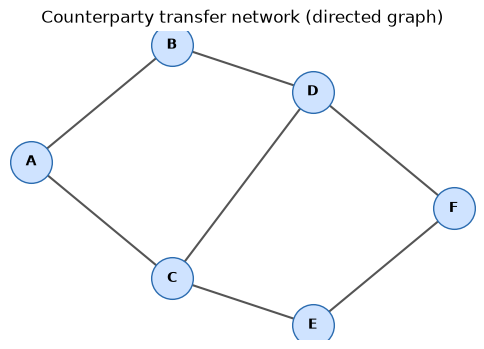

In [20]:
# Draw it (pure Matplotlib, fixed coordinates so it's stable across runs).
import matplotlib.pyplot as plt

pos = {"A": (0, 2), "B": (1, 3), "C": (1, 1), "D": (2, 2.6), "E": (2, 0.6), "F": (3, 1.6)}

plt.figure(figsize=(6, 4))
for src, neighbours in graph.items():
    x0, y0 = pos[src]
    for dst in neighbours:
        x1, y1 = pos[dst]
        plt.annotate("", xy=(x1, y1), xytext=(x0, y0),
                     arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))
for node, (x, y) in pos.items():
    plt.scatter(x, y, s=900, color="#cfe3ff", edgecolors="#2b6cb0", zorder=3)
    plt.text(x, y, node, ha="center", va="center", fontweight="bold", zorder=4)

plt.title("Counterparty transfer network (directed graph)")
plt.axis("off")
plt.show()

In [21]:
from collections import deque

def bfs(g, start):
    visited, order = {start}, []
    q = deque([start])            # a QUEUE -> level-by-level
    while q:
        node = q.popleft()
        order.append(node)
        for nbr in g[node]:
            if nbr not in visited:
                visited.add(nbr)
                q.append(nbr)
    return order

def dfs(g, start):
    visited, order = set(), []
    stack = [start]               # a STACK -> deep-first
    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            order.append(node)
            for nbr in reversed(g[node]):   # reversed -> natural left-to-right
                if nbr not in visited:
                    stack.append(nbr)
    return order

print("BFS from A:", bfs(graph, "A"))   # level by level
print("DFS from A:", dfs(graph, "A"))   # down each path

BFS from A: ['A', 'B', 'C', 'D', 'E', 'F']
DFS from A: ['A', 'B', 'D', 'F', 'C', 'E']


In [22]:
def bubble_sort(a):
    a = a[:]                      # work on a copy (pure function)
    n = len(a)
    for i in range(n):
        swapped = False
        for j in range(n - 1 - i):
            if a[j] > a[j + 1]:               # bubble the largest to the end
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True
        if not swapped:           # already sorted -> early exit (best case O(n))
            break
    return a

def selection_sort(a):
    a = a[:]
    n = len(a)
    for i in range(n):
        lo = i
        for j in range(i + 1, n):             # find the minimum in the rest
            if a[j] < a[lo]:
                lo = j
        a[i], a[lo] = a[lo], a[i]             # swap it into place
    return a

def insertion_sort(a):
    a = a[:]
    for i in range(1, len(a)):  
        key, j = a[i], i - 1
        while j >= 0 and a[j] > key:          # shift larger items right
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = key                        # drop key into the gap
    return a

data = [4200, 320, 9800, 75, 1500, 6000]
print("bubble   :", bubble_sort(data))
print("selection:", selection_sort(data))
print("insertion:", insertion_sort(data))
print("original unchanged:", data)           # proves the functions are pure

bubble   : [75, 320, 1500, 4200, 6000, 9800]
selection: [75, 320, 1500, 4200, 6000, 9800]
insertion: [75, 320, 1500, 4200, 6000, 9800]
original unchanged: [4200, 320, 9800, 75, 1500, 6000]


In [ ]:
# MERGESORT & QUICKSORT

def merge_sort(a):
    if len(a) <= 1:
        return a[:]
    mid = len(a) // 2
    left = merge_sort(a[:mid])                # solve each half
    right = merge_sort(a[mid:])
    merged, i, j = [], 0, 0                    # then merge them in order
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i]); i += 1
        else:
            merged.append(right[j]); j += 1
    merged.extend(left[i:]); merged.extend(right[j:])
    return merged

def quick_sort(a):
    if len(a) <= 1:
        return a[:]
    pivot = a[len(a) // 2]                     # pick a pivot
    less    = [x for x in a if x < pivot]      # partition around it
    equal   = [x for x in a if x == pivot]
    greater = [x for x in a if x > pivot]
    return quick_sort(less) + equal + quick_sort(greater)

print("merge:", merge_sort(data))
print("quick:", quick_sort(data))

merge: [75, 320, 1500, 4200, 6000, 9800]
quick: [75, 320, 1500, 4200, 6000, 9800]


In [24]:
# RADIX SORT

def radix_sort(a):
    a = a[:]
    if not a:
        return a
    max_val = max(a)
    exp = 1
    while max_val // exp > 0:                  # one pass per digit position
        buckets = [[] for _ in range(10)]
        for num in a:
            buckets[(num // exp) % 10].append(num)   # bucket by current digit
        a = [num for bucket in buckets for num in bucket]  # flatten in order
        exp *= 10
    return a

print("radix:", radix_sort(data))

radix: [75, 320, 1500, 4200, 6000, 9800]


In [25]:
# HEAP SORT

import heapq

def heap_sort(a):
    h = list(a)
    heapq.heapify(h)                          # O(n) build the heap
    return [heapq.heappop(h) for _ in range(len(h))]   # pop smallest each time

print("heap :", heap_sort(data))

heap : [75, 320, 1500, 4200, 6000, 9800]


In [27]:
# RACE

import random

def time_sort(fn, data):
    start = time.perf_counter()
    fn(data)
    return (time.perf_counter() - start) * 1000   # ms

sizes = [500, 1000, 2000, 4000]
algos = {
            "bubble": bubble_sort, 
            "selection": selection_sort, 
            "insertion": insertion_sort,
            "merge": merge_sort, 
            "quick": quick_sort, 
            "radix": radix_sort,
            "heap": heap_sort, 
            "sorted() built-in": sorted,
}

print(f"{'algorithm':18}", "  ".join(f"n={n}" for n in sizes))
results = {}
for name, fn in algos.items():
    row = []
    for n in sizes:
        sample = [random.randint(0, 10**6) for _ in range(n)]
        row.append(time_sort(fn, sample))
    results[name] = row
    print(f"{name:18}", "  ".join(f"{t:6.1f}" for t in row), "ms")

algorithm          n=500  n=1000  n=2000  n=4000
bubble               15.5    78.2   160.2   651.3 ms
selection             3.9    17.4    68.8   301.9 ms
insertion             5.2    18.9    85.0   339.8 ms
merge                 0.7     1.4     4.3     6.5 ms
quick                 0.7     1.7     3.3     6.9 ms
radix                 0.3     0.5     0.9     1.8 ms
heap                  0.1     0.3     0.5     0.9 ms
sorted() built-in     0.0     0.1     0.2     0.4 ms


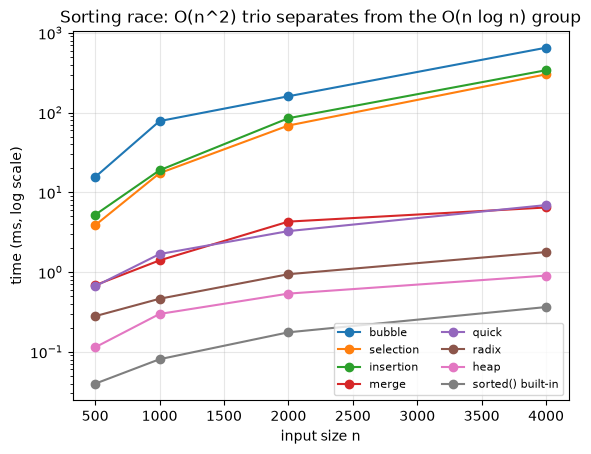

In [28]:
# Plot the race. Log scale on y so the fast algorithms don't flatten to zero.

import matplotlib.pyplot as plt

for name, row in results.items():
    plt.plot(sizes, row, marker="o", label=name)
plt.yscale("log")
plt.xlabel("input size n")
plt.ylabel("time (ms, log scale)")
plt.title("Sorting race: O(n^2) trio separates from the O(n log n) group")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

#### Complexity reference

| Algorithm | Best | Average | Worst | Space | Stable? |
|---|---|---|---|---|---|
| Bubble | O(n) | O(n²) | O(n²) | O(1) | yes |
| Selection | O(n²) | O(n²) | O(n²) | O(1) | no |
| Insertion | O(n) | O(n²) | O(n²) | O(1) | yes |
| Merge | O(n log n) | O(n log n) | O(n log n) | O(n) | yes |
| Quick | O(n log n) | O(n log n) | O(n²)* | O(log n) | no |
| Heap | O(n log n) | O(n log n) | O(n log n) | O(1) | no |
| Radix | O(nk) | O(nk) | O(nk) | O(n+k) | yes |